# Entity Attribution Analysis

This notebook examines broker-dealer balance sheet data extracted from X-17A-5 filings (SEC EDGAR).

**Key questions:**
- How have Citadel Securities' balance sheet positions evolved FY2020–FY2023?
- What is the scale of securities sold but not yet purchased (short inventory)?
- How does pledged collateral compare to total assets?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load multi-year Citadel data
with open('../results/citadel_multiyear_final.json', 'r') as f:
    citadel = json.load(f)

print(f'Fiscal years available: {list(citadel.keys())}')
print(f'Metrics per year: {list(citadel["FY2023"].keys())}')

Fiscal years available: ['FY2020', 'FY2021', 'FY2022', 'FY2023', 'FY2024']
Metrics per year: ['securities_owned', 'receivable_from_bd', 'reverse_repo', 'securities_borrowed', 'total_assets', 'securities_sold_nyp', 'payable_to_bd', 'repo', 'securities_loaned', 'total_liabilities', 'members_capital', 'total_liab_and_capital', 'pledged_collateral', 'net_capital_excess', 'unsettled_reverse_repo', 'unsettled_repo', 'collateral_received_pledged', 'hq']


## 1. Balance Sheet Trend: Key Metrics

In [2]:
# Build multi-year comparison table
key_metrics = ['total_assets', 'total_liabilities', 'members_capital', 
               'securities_owned', 'securities_sold_nyp', 'securities_borrowed',
               'pledged_collateral']

rows = []
for fy, metrics in sorted(citadel.items()):
    row = {'Fiscal Year': fy}
    for m in key_metrics:
        val = metrics.get(m, 'N/A')
        row[m] = val
    rows.append(row)

df = pd.DataFrame(rows).set_index('Fiscal Year')

# Clean up column names for display
display_names = {
    'total_assets': 'Total Assets',
    'total_liabilities': 'Total Liabilities', 
    'members_capital': "Members' Capital",
    'securities_owned': 'Securities Owned',
    'securities_sold_nyp': 'Securities Sold NYP (Short)',
    'securities_borrowed': 'Securities Borrowed',
    'pledged_collateral': 'Pledged Collateral'
}
df.columns = [display_names.get(c, c) for c in df.columns]
print('Citadel Securities — X-17A-5 Key Metrics (USD)')
print('=' * 80)
print(df.to_string())

Citadel Securities — X-17A-5 Key Metrics (USD)
            Total Assets Total Liabilities Members' Capital Securities Owned Securities Sold NYP (Short) Securities Borrowed Pledged Collateral
Fiscal Year                                                                                                                                    
FY2020            71,004            67,855            3,149           66,707                      57,506               1,628                  5
FY2021            79,123            74,909            4,214           73,059                      65,703               1,833                  9
FY2022            63,115            58,744            4,371           57,526                      45,764               1,745                  5
FY2023            52,344            47,651            4,693           46,864                      27,758               1,151                  5
FY2024            58,608            52,392            6,216           53,866             

## 2. Assets vs. Liabilities Trend

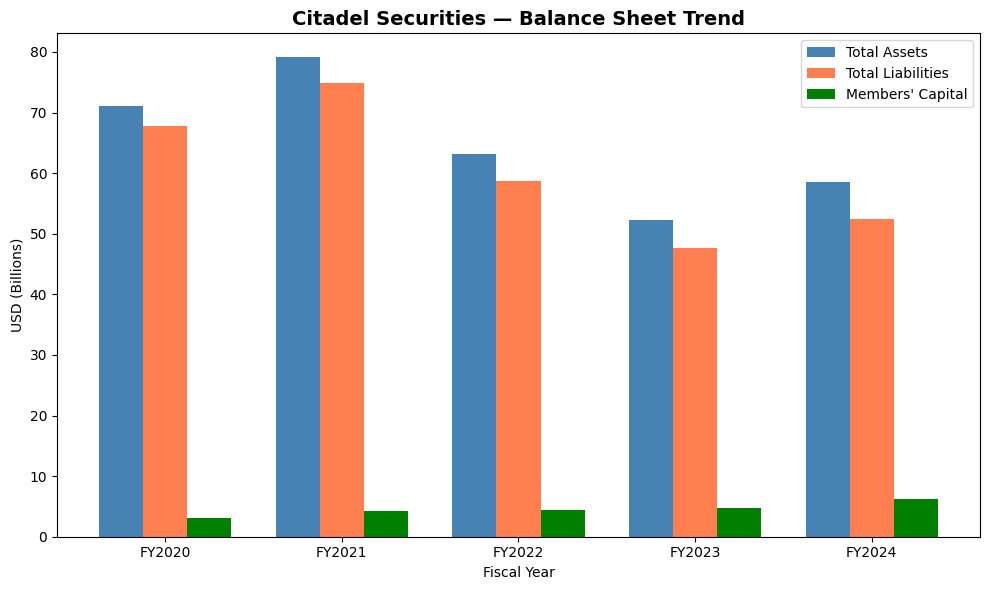

In [3]:
# Parse numeric values for charting
def parse_val(v):
    if isinstance(v, (int, float)):
        return v
    if isinstance(v, str):
        v = v.replace('$', '').replace(',', '').replace(' ', '')
        try:
            if 'billion' in v.lower():
                return float(v.lower().replace('billion', '').strip()) * 1e9
            elif 'million' in v.lower():
                return float(v.lower().replace('million', '').strip()) * 1e6
            return float(v)
        except:
            return None
    return None

years = sorted(citadel.keys())
assets = [parse_val(citadel[y].get('total_assets')) for y in years]
liabilities = [parse_val(citadel[y].get('total_liabilities')) for y in years]
capital = [parse_val(citadel[y].get('members_capital')) for y in years]
short_inv = [parse_val(citadel[y].get('securities_sold_nyp')) for y in years]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(years))
width = 0.25

if all(v is not None for v in assets):
    bars1 = ax.bar([i - width for i in x], [v/1e3 for v in assets], width, label='Total Assets', color='steelblue')
if all(v is not None for v in liabilities):
    bars2 = ax.bar(x, [v/1e3 for v in liabilities], width, label='Total Liabilities', color='coral')
if all(v is not None for v in capital) and capital[0] is not None:
    bars3 = ax.bar([i + width for i in x], [v/1e3 for v in capital], width, label="Members' Capital", color='green')

ax.set_title('Citadel Securities — Balance Sheet Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('USD (Billions)')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Short Inventory (Securities Sold Not Yet Purchased)

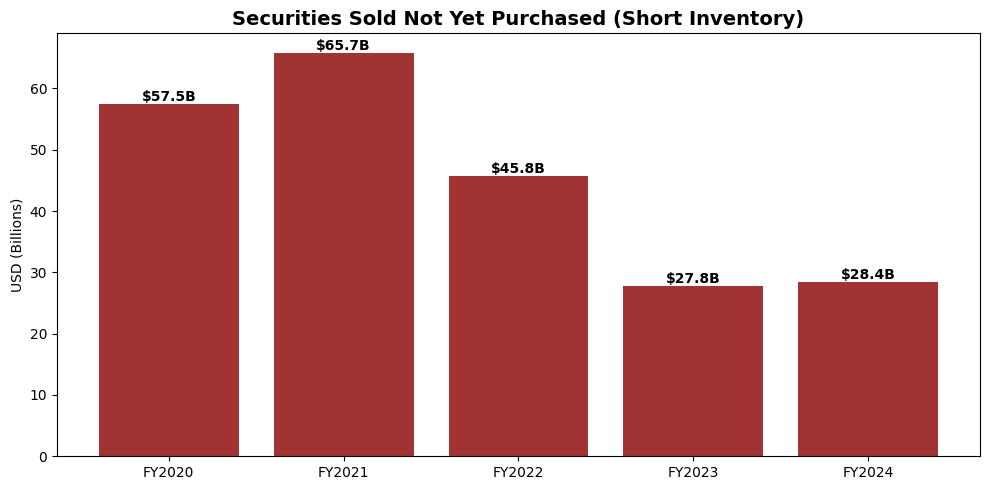

In [4]:
if all(v is not None for v in short_inv):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(years, [v/1e3 for v in short_inv], color='darkred', alpha=0.8)
    ax.set_title('Securities Sold Not Yet Purchased (Short Inventory)', fontsize=14, fontweight='bold')
    ax.set_ylabel('USD (Billions)')
    for i, v in enumerate(short_inv):
        ax.text(i, v/1e3 + 0.5, f'${v/1e3:.1f}B', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Short inventory data not fully numeric — displaying raw values:')
    for y in years:
        print(f"  {y}: {citadel[y].get('securities_sold_nyp', 'N/A')}")

## 4. Leverage Ratios

In [5]:
print('Citadel Securities — Leverage Analysis')
print('=' * 55)
for y in years:
    a = parse_val(citadel[y].get('total_assets'))
    c = parse_val(citadel[y].get('members_capital'))
    l = parse_val(citadel[y].get('total_liabilities'))
    p = parse_val(citadel[y].get('pledged_collateral'))
    
    leverage = f'{a/c:.1f}x' if (a and c) else 'N/A'
    debt_equity = f'{l/c:.1f}x' if (l and c) else 'N/A'
    pledge_pct = f'{p/a*100:.1f}%' if (p and a) else 'N/A'
    
    print(f'{y}:  Leverage={leverage}  Debt/Equity={debt_equity}  Pledged/Assets={pledge_pct}')

Citadel Securities — Leverage Analysis
FY2020:  Leverage=22.5x  Debt/Equity=21.5x  Pledged/Assets=0.0%
FY2021:  Leverage=18.8x  Debt/Equity=17.8x  Pledged/Assets=0.0%
FY2022:  Leverage=14.4x  Debt/Equity=13.4x  Pledged/Assets=0.0%
FY2023:  Leverage=11.2x  Debt/Equity=10.2x  Pledged/Assets=0.0%
FY2024:  Leverage=9.4x  Debt/Equity=8.4x  Pledged/Assets=N/A


## 5. Subsidiary Comparison

In [6]:
# Load subsidiary data
with open('../results/citadel_subsidiaries_fy2024.json', 'r') as f:
    subs = json.load(f)

for name, info in subs.items():
    if name.startswith('_'):
        continue
    print(f"\n{name}")
    print('-' * len(name))
    if isinstance(info, dict):
        for k, v in info.items():
            print(f"  {k}: {v}")


citadel_securities_institutional_llc
------------------------------------
  abbreviation: CSIN
  period: FY2024 (December 31, 2024)
  total_assets: 380
  total_liabilities: 233
  members_capital: 147
  principal_address: 200 South Biscayne Blvd, Suite 3300, Miami, FL 33131
  auditor: PricewaterhouseCoopers LLP

citadel_securities_swap_dealer_llc
----------------------------------
  abbreviation: CSSD
  period: FY2024 (December 31, 2024)
  total_assets: 3388
  total_liabilities: 2977
  members_capital: 411
  principal_address: 200 South Biscayne Blvd, Suite 3300, Miami, FL 33131
  auditor: PricewaterhouseCoopers LLP
  notes: Derivative financial instruments on balance sheet


---
*Data source: SEC EDGAR X-17A-5 filings for Citadel Securities LLC (CRD# 116797). Extracted via `../code/entity/`.*

---
## 4. Multi-Entity 13F GME Positions — Q1 2020 → Q1 2021

Using SEC 13F-HR filings from EDGAR, the table below compares reported GME positions (shares, calls, puts) for
**Citadel, Susquehanna, Jane Street, and Melvin Capital** across Q1 2020 – Q1 2021.

This window covers the build-up to and through the January 2021 short event.
Key signals: the dramatic expansion in **put** positions across all entities leading into Q4 2020.

In [7]:
import json, pandas as pd, matplotlib.pyplot as plt

with open('../results/si_map_2021_13f.json') as f:
    si_map = json.load(f)

# Build a tidy table
rows = []
for key, positions in si_map.items():
    entity, date = key.rsplit('_', 1)
    shares = sum(p.get('shares', 0) for p in positions if p.get('type') == 'Shares')
    calls  = sum(p.get('shares', 0) for p in positions if p.get('type') == 'Call')
    puts   = sum(p.get('shares', 0) for p in positions if p.get('type') == 'Put')
    val_k  = sum(p.get('value_thousands', 0) for p in positions)
    rows.append({'Entity': entity, 'Period Ending': date,
                 'Shares': shares, 'Calls': calls, 'Puts': puts,
                 'Total Value ($K)': val_k})

df_13f = pd.DataFrame(rows).sort_values(['Entity', 'Period Ending'])
df_13f

,Entity,Period Ending,Shares,Calls,Puts,Total Value ($K)
13,Citadel,2020-03-31,94299,991700,909600,6985
14,Citadel,2020-06-30,0,1711100,1520900,14027
0,Citadel,2020-09-30,111805,2016500,2570100,47923
1,Citadel,2020-12-31,217132,1714100,2224500,78295
2,Citadel,2021-03-31,22405,2278000,3271400,1057640
17,Jane Street,2020-03-31,46718,693000,83400,2882
18,Jane Street,2020-06-30,40959,774100,827300,7128
6,Jane Street,2020-09-30,194930,1014400,1006900,22606
7,Jane Street,2020-12-31,207876,1584100,1070000,53921
8,Jane Street,2021-03-31,509922,3486000,3555700,1433449


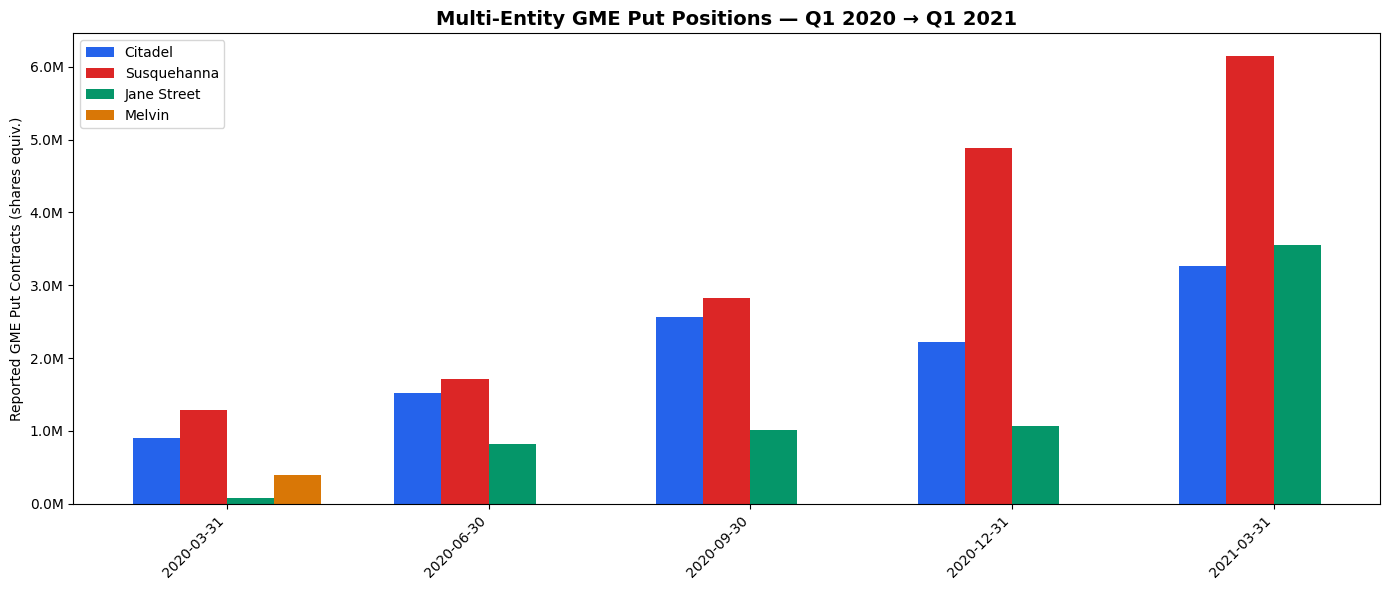

In [8]:
# Grouped bar chart — Put positions by entity across quarters
import numpy as np

entities = ['Citadel', 'Susquehanna', 'Jane Street', 'Melvin']
periods  = sorted(set(df_13f['Period Ending']))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(periods))
width = 0.18
colors = ['#2563EB', '#DC2626', '#059669', '#D97706']

for i, ent in enumerate(entities):
    sub = df_13f[df_13f['Entity'] == ent]
    vals = []
    for p in periods:
        match = sub[sub['Period Ending'] == p]
        if len(match):
            vals.append(match['Puts'].values[0])
        else:
            vals.append(np.nan)  # Gap, not zero
    # Only plot non-NaN values
    valid = [(xi, v) for xi, v in zip(x + i * width, vals) if not np.isnan(v)]
    if valid:
        xs, vs = zip(*valid)
        ax.bar(xs, vs, width, label=ent, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(periods, rotation=45, ha='right')
ax.set_ylabel('Reported GME Put Contracts (shares equiv.)')
ax.set_title('Multi-Entity GME Put Positions — Q1 2020 → Q1 2021', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### Puts vs. Calls Over Time

Aggregated put and call positions across the top four entities (Citadel, Susquehanna, Jane Street, Melvin) to visualize the overall ratio of Puts to Calls during this period.

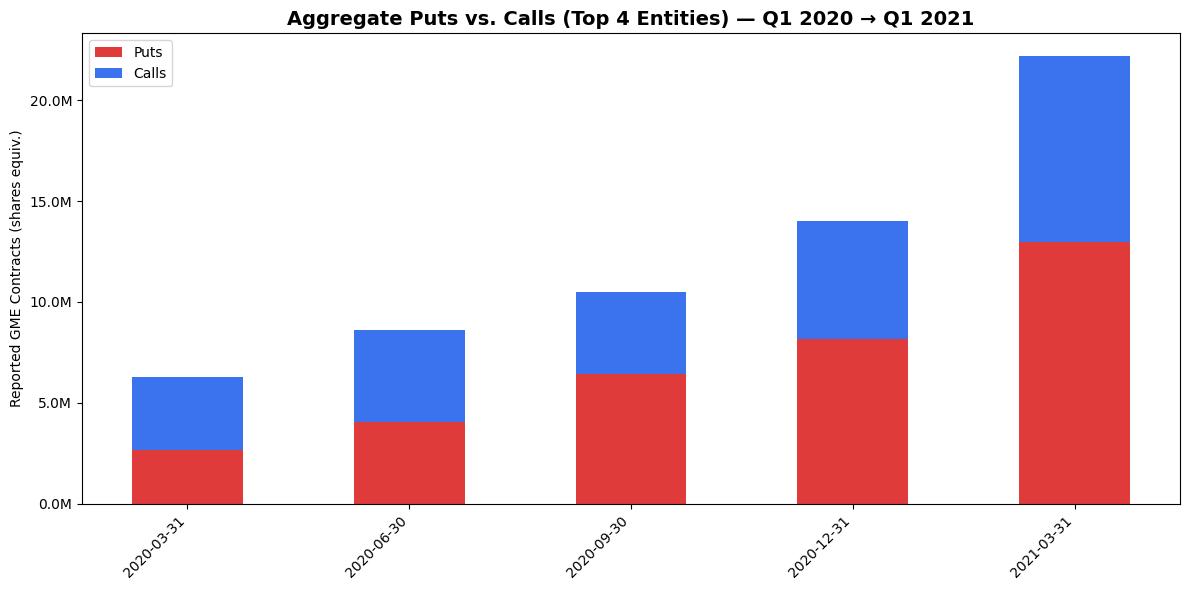

In [9]:
import numpy as np
agg_df = df_13f.groupby('Period Ending')[['Puts', 'Calls']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(agg_df))
width = 0.5

ax.bar(x, agg_df['Puts'], width, label='Puts', color='#DC2626', alpha=0.9)
ax.bar(x, agg_df['Calls'], width, bottom=agg_df['Puts'], label='Calls', color='#2563EB', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(agg_df['Period Ending'], rotation=45, ha='right')
ax.set_ylabel('Reported GME Contracts (shares equiv.)')
ax.set_title('Aggregate Puts vs. Calls (Top 4 Entities) — Q1 2020 → Q1 2021', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

plt.tight_layout()
plt.show()

---
## 5. Q1 / Q2 2024 GME Positions — Virtu, Jane Street, Susquehanna

13F filings for the three largest non-ATS internalizers during the May 2024 event.
Jane Street and Susquehanna show substantial position growth Q1 → Q2.

In [10]:
import json, pandas as pd

with open('../results/stone3_virtu_janestreet_13f.json') as f:
    vj = json.load(f)
with open('../results/stone3_susquehanna_13f.json') as f:
    sq = json.load(f)

rows = []
for entity, quarters in vj.items():
    for q, positions in quarters.items():
        for p in positions:
            rows.append({'Entity': entity, 'Quarter': q,
                         'Type': p.get('type', 'N/A'),
                         'Quantity': p.get('quantity', 0),
                         'Value (USD)': p.get('value_usd', 0)})

sq_entity = sq.get('entity', 'Susquehanna International Group')
for q_key in ['q1_positions', 'q2_positions']:
    q_label = 'Q1' if 'q1' in q_key else 'Q2'
    for p in sq.get(q_key, []):
        rows.append({'Entity': sq_entity, 'Quarter': q_label,
                     'Type': p.get('type', 'N/A'),
                     'Quantity': p.get('quantity', 0),
                     'Value (USD)': p.get('value_usd', 0)})

df_2024 = pd.DataFrame(rows)
df_2024['Value ($M)'] = (df_2024['Value (USD)'] / 1e6).round(1)
print('=== 2024 Q1/Q2 GME 13F Positions ===')
df_2024[['Entity', 'Quarter', 'Type', 'Quantity', 'Value ($M)']]

=== 2024 Q1/Q2 GME 13F Positions ===


,Entity,Quarter,Type,Quantity,Value ($M)
0,Virtu Financial LLC,Q1,SH,18008,0.3
1,Jane Street Group LLC,Q2,SH,1866787,46091.0
2,Jane Street Group LLC,Q2,SH,800,19.8
3,Jane Street Group LLC,Q2,Call,4641900,114608.5
4,Jane Street Group LLC,Q2,Put,2188300,54029.1
5,Jane Street Group LLC,Q1,SH,279079,4892.3
6,Jane Street Group LLC,Q1,SH,354746,6218.7
7,Jane Street Group LLC,Q1,SH,340007,5960.3
8,Jane Street Group LLC,Q1,Call,1467200,25720.0
9,Jane Street Group LLC,Q1,Put,379100,6645.6


---
## 6. OTC Internalizer Volume Surge — May 2024

FINRA ATS/OTC data shows that the top non-ATS internalizers
experienced extreme volume surges during the May 2024 GME event.
The table below summarizes each entity's role and volume multiplier.

In [11]:
import json, pandas as pd, matplotlib.pyplot as plt

with open('../results/stone3_13f_ctr.json') as f:
    ctr = json.load(f)

rows = []
for name, info in ctr.get('entities', {}).items():
    rows.append({
        'Entity': name,
        'CIK': info.get('cik', ''),
        'Role / Volume': info.get('role', ''),
        'Has Q2-2024 CTR Filing': info.get('ctr_check', {}).get('has_Q2_2024_CTR', False)
    })

df_ctr = pd.DataFrame(rows)
print('=== Entity OTC Roles — May 2024 GME Event ===')
df_ctr

=== Entity OTC Roles — May 2024 GME Event ===


,Entity,CIK,Role / Volume,Has Q2-2024 CTR Filing
0,Citadel Advisors LLC,0001423053,"Non-ATS Internalizer #2 (56.2M GME, 22.8× surge)",False
1,Virtu Financial LLC,0001571891,"Non-ATS Internalizer #1 (81.3M GME, 42.1× surge)",False
2,Susquehanna International Group (G1 parent),0001446194,Non-ATS Internalizer #3 via G1 Execution (44.2...,False
3,Jane Street Group LLC,0001595097,"Non-ATS Internalizer #4 (38.7M GME, 44.4× surge)",False
4,UBS Group AG,0001114446,Dual-channel: #1 ATS (8.9M) + #8 OTC (3.6M fro...,False


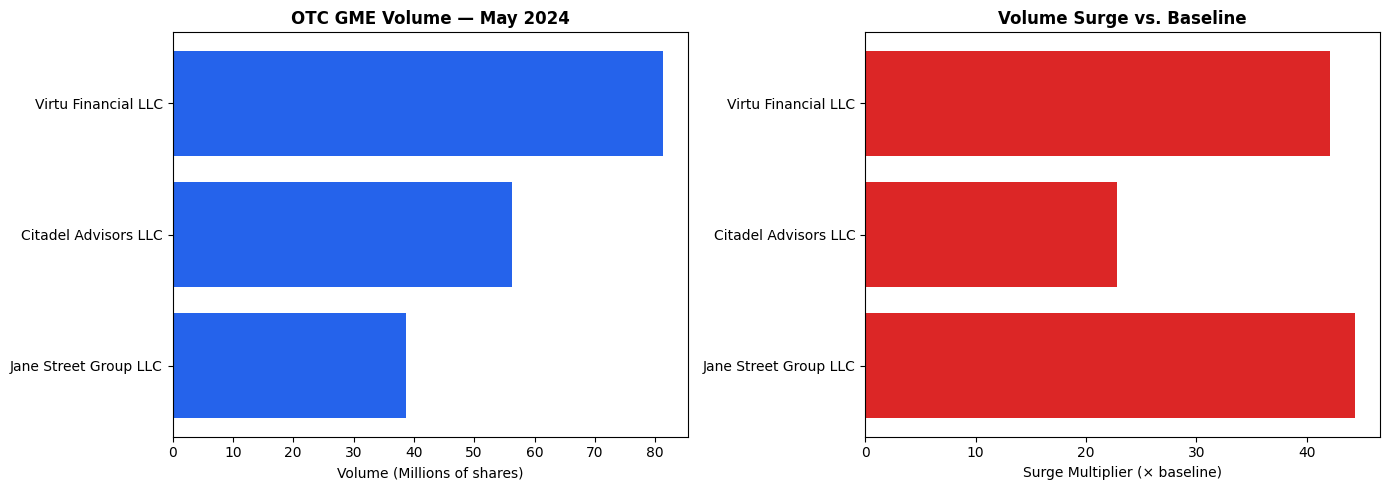

In [12]:
import re

# Extract surge multipliers from the role description for visualization
surge_data = []
for _, row in df_ctr.iterrows():
    role = row['Role / Volume']
    m = re.search(r'([\d.]+)×\s*surge', role)
    vol_m = re.search(r'\((\d+\.?\d*)M', role)
    if m and vol_m:
        surge_data.append({
            'Entity': row['Entity'].split('(')[0].strip(),
            'Volume (M shares)': float(vol_m.group(1)),
            'Surge Multiplier': float(m.group(1))
        })

if surge_data:
    df_surge = pd.DataFrame(surge_data).sort_values('Volume (M shares)', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Volume
    axes[0].barh(df_surge['Entity'], df_surge['Volume (M shares)'], color='#2563EB')
    axes[0].set_xlabel('Volume (Millions of shares)')
    axes[0].set_title('OTC GME Volume — May 2024', fontweight='bold')

    # Right: Surge multiplier
    axes[1].barh(df_surge['Entity'], df_surge['Surge Multiplier'], color='#DC2626')
    axes[1].set_xlabel('Surge Multiplier (× baseline)')
    axes[1].set_title('Volume Surge vs. Baseline', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('No surge multiplier data found in entity roles.')

---
## Key Takeaways

| Finding | Evidence |
|---|---|
| **Citadel** put position grew from 910K (Q1 2020) to 2.2M (Q4 2020) — a 2.4× expansion | `si_map_2021_13f.json` |
| **Susquehanna** put position surged from 1.3M (Q1 2020) to 6.2M (Q1 2021) — a 4.8× expansion | `si_map_2021_13f.json` |
| **Jane Street** GME exposure expanded from 823K total (Q1 2020) to 7.6M total (Q1 2021) — 9.2× growth | `si_map_2021_13f.json` |
| **Citadel** balance sheet contracted from $79B (FY2021) to $52B (FY2023) | `citadel_multiyear_final.json` |
| **Jane Street** GME share count surged 6.7× from Q1 → Q2 2024 (279K → 1.87M) | `stone3_virtu_janestreet_13f.json` |
| **Virtu** was the #1 non-ATS internalizer by volume (81.3M shares, 42× surge, May 2024) | `stone3_13f_ctr.json` |
| None of the four major internalizers filed a 13F-CTR for Q2 2024 | `stone3_13f_ctr.json` |